# Mexico Real Estate Analysis

## Visualizing Housing Data

### Research Question

> Are property prices in Mexico more strongly associated with
> property size or location?

### Objective

This notebook builds on the cleaned dataset produced during the
data preparation stage.

The goal is to use data visualization to understand the
distribution of property prices and sizes, compare prices across
locations and property types, and investigate the relationship
between property size and price.

Visualization is used before formal statistical analysis because
summary statistics alone can hide important patterns such as
skewness, outliers, clustering, and differences between groups.

### This Notebook

In this notebook, I will:

1. Load and verify the cleaned dataset
2. Build distributions of property prices and sizes
3. Compare property prices across property types and states
4. Visualize the relationship between property size and price
5. Investigate the effect of extreme observations
6. Add regression trendlines
7. Examine how the size-price relationship varies by state

The visual patterns identified here will guide the statistical
analysis performed in subsequent notebooks.

## 1. Import Libraries

The analysis uses pandas for data manipulation, Matplotlib for
plot construction, and Seaborn for statistical visualizations.

Matplotlib provides the underlying figure and axes objects, while
Seaborn provides higher-level statistical plotting functionality.

In [26]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Clean Dataset

The previous notebook produced a cleaned and standardized dataset
containing property type, location, area, and price information.

Rather than repeating the cleaning process, this notebook uses the
saved analytical dataset as its input.

This separation keeps the workflow reproducible:

Raw Data → Data Cleaning → Clean Dataset → Visualization

In [27]:
# Path to the cleaned dataset
data_path = "../data/mexico-real-estate-combined-clean.csv"

# Load the cleaned dataset
df = pd.read_csv(data_path)

## 3. Verify the Dataset

Before creating visualizations, I verify that the expected
variables are present and that the numerical variables have
appropriate data types.

This is a small but important reproducibility check. Visualization
should be performed on the validated analytical dataset rather than
assuming that the saved file is unchanged.

In [28]:
# Display the dataset dimensions
df.shape

(1736, 6)

In [29]:
# Display the column names
df.columns.tolist()

['property_type', 'state', 'lat', 'lon', 'area_m2', 'price_usd']

In [30]:
# Check data types
df.dtypes

property_type        str
state                str
lat              float64
lon              float64
area_m2          float64
price_usd        float64
dtype: object

In [31]:
# Check for missing values
df.isnull().sum()

property_type    0
state            0
lat              0
lon              0
area_m2          0
price_usd        0
dtype: int64

### Verification Result

The dataset contains the six standardized variables required for
the analysis:

- `property_type`
- `state`
- `lat`
- `lon`
- `area_m2`
- `price_usd`

The numerical variables `area_m2` and `price_usd` are stored as
numeric values, and the dataset contains no missing values in the
retained observations.

The data is therefore ready for exploratory visualization.

## 4. Matplotlib's Figure and Axes Interface

For the visual analysis, I will use Matplotlib's explicit
object-oriented interface.

The standard pattern is:

```python
fig, ax = plt.subplots()
```
**fig** represents the overall figure or canvas.

**ax** represents the plotting area.
The visualization is then created by calling methods on the specific Axes object

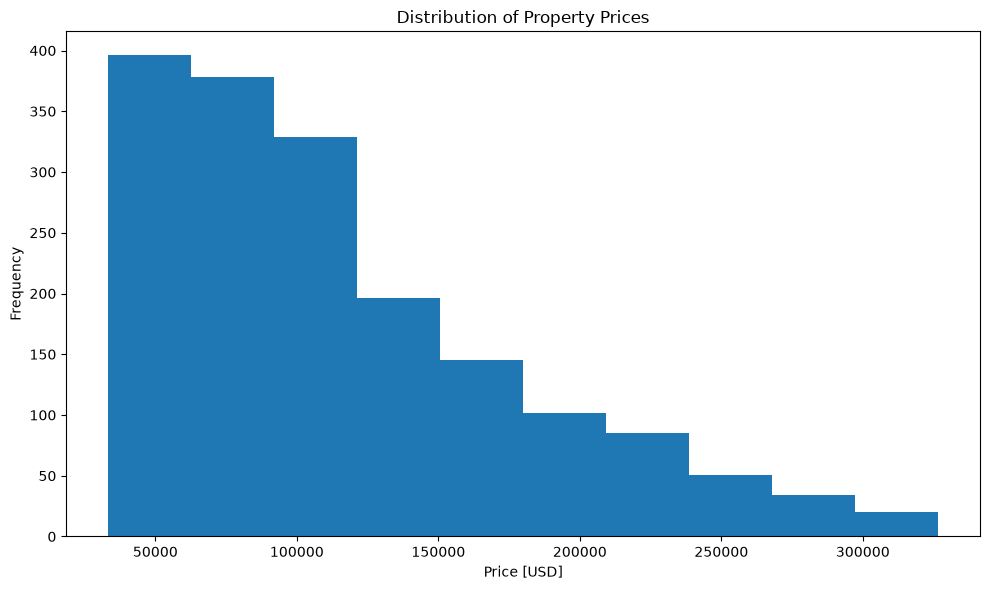

In [32]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the data
ax.hist(df["price_usd"])

# Add labels and title
ax.set_xlabel("Price [USD]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Prices")

# Improving spacing and display
plt.tight_layout()
plt.show()




### Distribution of Property Prices

The histogram shows that property prices are not evenly distributed.

Most observations are concentrated toward the lower end of the
price range, while a smaller number of properties extend toward
substantially higher prices.

This creates a **right-skewed distribution**.

The long right tail is important because it explains why the mean
price is higher than the median observed in the previous notebook.

The visualization therefore confirms an important limitation of
using the mean alone to describe the typical property price.

## 5. Distribution of Property Sizes

Price is only one of the variables relevant to the research
question.

Property size is the second major numerical variable, so its
distribution should also be examined before investigating the
relationship between size and price.

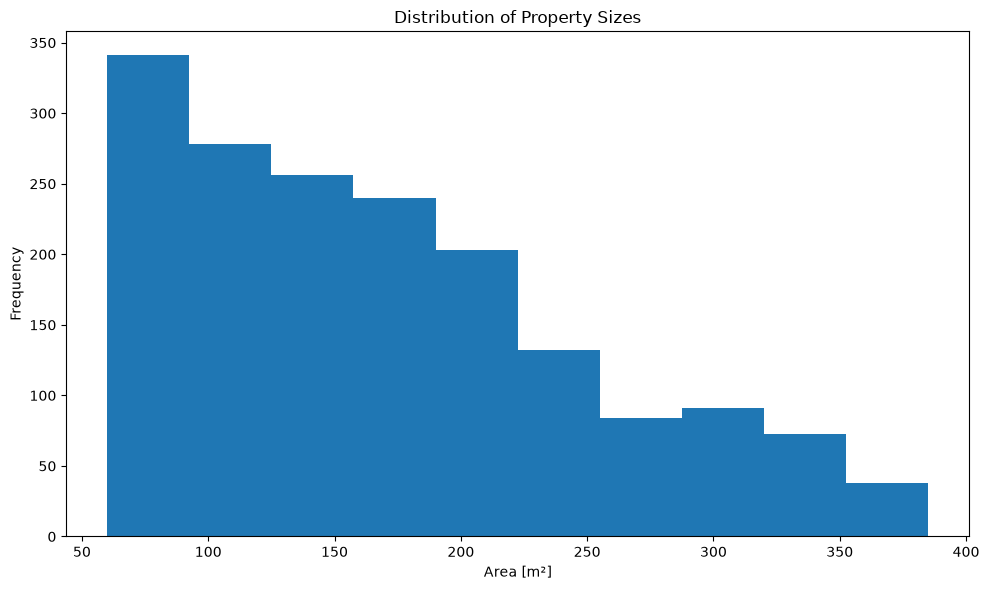

In [33]:
# Create a histogram of property sizes
fig,ax =plt.subplots(figsize=(10,6))

ax.hist(df["area_m2"])
ax.set_xlabel("Area [m²]")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Property Sizes")

plt.tight_layout()
plt.show()

### Distribution of Property Sizes

Property sizes are also concentrated toward the lower end of the
observed range, with fewer observations representing substantially
larger properties.

The distribution therefore shows evidence of right skewness.

This matters for the later size-price analysis because extreme
property sizes can influence both the visual appearance of a
scatterplot and statistical measures such as correlation.

## 6. Comparing Property Prices with Boxplots

Histograms are useful for understanding the distribution of a single
numerical variable. However, they become less practical when we want
to compare the distribution of a numerical variable across several
groups.

A boxplot provides a compact summary of a distribution using the
median, quartiles, whiskers, and potential outliers.

In this section, I will compare property prices across different
property types and states.

### Understanding a Boxplot

A boxplot summarizes the distribution using:

- **Median** - the middle observation
- **Q1** - the 25th percentile
- **Q3** - the 75th percentile
- **IQR** - the range between Q1 and Q3
- **Whiskers** - the typical range of observations
- **Outliers** - observations beyond the whiskers

For this analysis, the median is particularly useful because the
price distribution is right-skewed and therefore sensitive to
extreme values.

### Price Distribution by Property Type

I first compare property prices between the different property
types in the dataset.

A horizontal boxplot is used because property-type names are
categorical labels, while price is a continuous numerical variable.

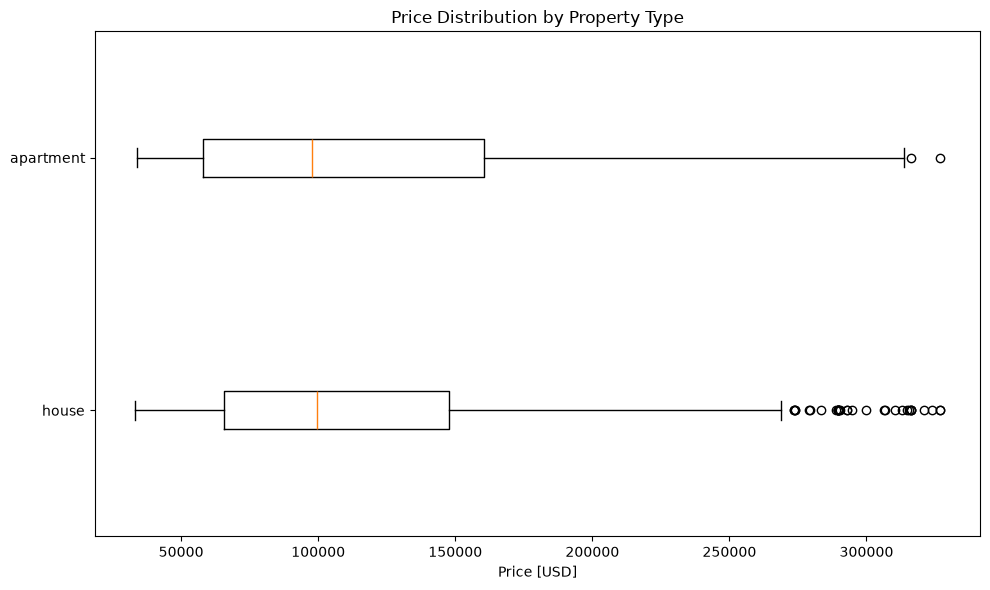

In [34]:
# Identify the property types
prop_types = df["property_type"].unique()

# Collect prices for each property type
data_by_type = [
     # Select rows for the current property type
     # Then select only the price_usd column
    df[df["property_type"] ==label]["price_usd"]
     # Repeat this for every property type
    for label in prop_types
]

# Display the collected prices
#data_by_type

# Create the boxplot
fig, ax = plt.subplots(figsize=(10,6))

ax.boxplot(
    data_by_type,
    tick_labels = prop_types,
    orientation = "horizontal"
    
)
ax.set_xlabel("Price [USD]")
ax.set_title("Price Distribution by Property Type")

plt.tight_layout()
plt.show()

### Interpretation

The boxplot allows the distributions of the property types to be
compared using their medians and overall spread.

The median provides the most useful first comparison because the
price distributions contain extreme high-value properties.

The presence of observations beyond the whiskers also confirms that
the housing market contains properties with prices substantially
different from the typical listing.

This reinforces the importance of considering the full distribution
rather than relying only on the mean price.

### Price Distribution by State

Location is one of the main factors in the research question.

The dataset contains many states, so plotting every state at once
could make the visualization difficult to interpret.

I will therefore begin by selecting the three states with the
largest number of property listings.

This provides a comparison using groups with sufficient observations
while keeping the visualization readable.

In [35]:
# Identify the three states with the most listings
selected_states = (
    df["state"]
    .value_counts()
    .head(3)
   .index 
    .tolist()
)
selected_states

['Distrito Federal', 'Estado de México', 'Yucatán']

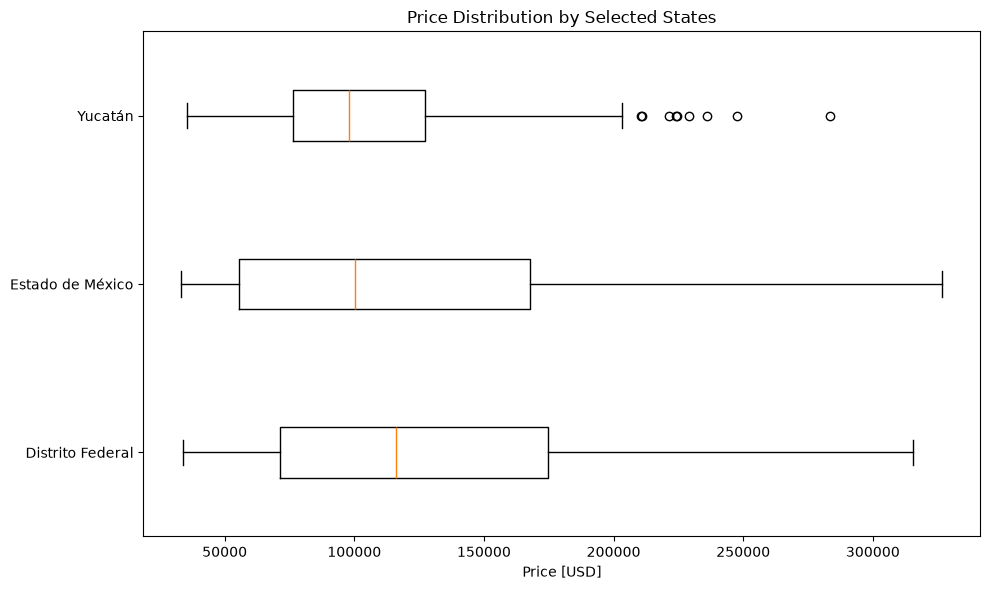

In [36]:
# Collect prices for each selected state
data_by_state = [
    df[df["state"] == state]["price_usd"]
    for state in selected_states
]
# Create the boxplot
fig, ax = plt.subplots(figsize=(10,6))
ax.boxplot(
    data_by_state,
    tick_labels=selected_states,
    orientation ="horizontal"
)
ax.set_xlabel("Price [USD]")
ax.set_title("Price Distribution by Selected States")

plt.tight_layout()
plt.show()

### Interpretation

The boxplot shows that property prices vary across states.

Differences in the median prices suggest that location is associated
with the price level of properties.

The widths of the boxes also show that the amount of price
variation differs between markets. A wider box indicates greater
variation among the middle 50% of listings.

The outliers reveal that some states contain properties belonging to
a substantially higher-priced segment.

This provides initial visual evidence that **location may be an
important factor in property prices**.

However, the boxplot does not tell us whether location explains more
variation in price than property size. That question requires
examining the relationship between the numerical variables directly.

## 7. Relationship Between Property Size and Price

The second major part of the research question concerns property
size.

To investigate whether larger properties tend to have higher
prices, I use a scatterplot.

A scatterplot represents each property as a single point:

- The x-axis represents property area in square meters.
- The y-axis represents property price in US dollars.

This allows the direction, strength, form, and unusual observations
in the relationship to be examined visually.

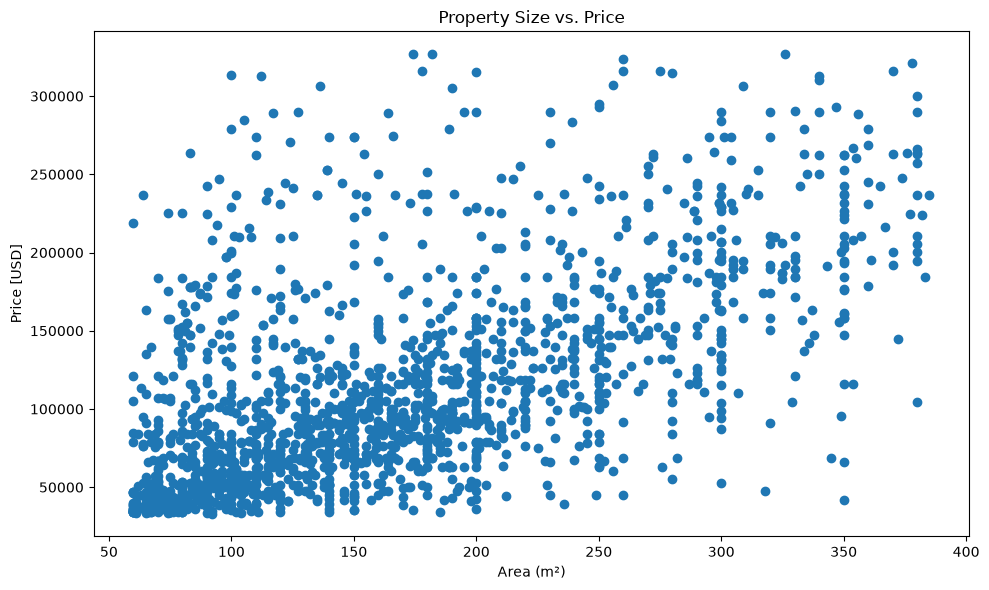

In [37]:
# Create a scatterplot of property size and price
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    x = df["area_m2"],
    y = df["price_usd"]
)
ax.set_xlabel("Area (m²)")
ax.set_ylabel("Price [USD]")
ax.set_title("Property Size vs. Price")

plt.tight_layout()
plt.show()

### Reading the Scatterplot

The scatterplot provides several features to examine:

- **Direction:** whether price generally increases as area increases
- **Strength:** how closely observations follow a common pattern
- **Form:** whether the relationship appears linear or curved
- **Outliers:** observations that are far from the main cluster

The plot shows a general positive relationship: larger properties
tend to have higher prices.

However, the observations are widely scattered. Properties with
similar areas can have substantially different prices.

This suggests that property size is associated with price, but size
alone does not explain the entire variation in property prices.

## 8. Investigating Extreme Observations

The raw scatterplot shows that most properties are concentrated in a
relatively small region, while a few observations extend much farther
along the area and price axes.

These extreme observations can make the main relationship difficult
to see because the plotting scale must accommodate them.

Before removing anything, I will examine the distributions and use
quantiles to identify the range containing the core market.

In [38]:
# Examine the upper quantiles of price and area
df[["price_usd", "area_m2"]].quantile(
    [0.05, 0.75,0.8, 0.90, 0.95, 0.99]
)

,price_usd,area_m2
0.05,39232.060000,70.0
0.75,150846.665000,220.0
0.80,168421.052632,240.0
0.90,210795.910000,298.0
0.95,247472.892500,330.0
0.99,306086.579263,375.3


### Why Use Quantiles?

A quantile describes the position of a value within a distribution.

For example, the 90th percentile is the value below which 90% of
the observations fall.

Using quantiles is preferable to choosing arbitrary fixed cutoffs
because the thresholds are based on the distribution of the data.

For this analysis, I will define a core-market dataset by:

- Removing the lowest 5% of prices
- Removing the highest 10% of prices
- Removing the largest 10% of properties by area

This asymmetric treatment reflects the longer upper tails visible
in the distributions.

## 9. Create a Core-Market Dataset

The goal of this filtering step is not to claim that extreme
properties are invalid.

Luxury properties and unusually large properties can be genuine
observations. However, they can dominate the visual scale and make
the relationship among typical properties difficult to see.

I therefore create a separate dataset representing the core market.

The original dataset will be preserved so that the full market
remains available for later analysis.

In [39]:
# Define quantile cutoffs
lower_cut = 0.05
upper_cut = 0.90

# Create a core-market dataset
df_clean = df[
    (
        df["price_usd"] > df["price_usd"].quantile(lower_cut)

    ) &
     (
    df["price_usd"] < df["price_usd"].quantile(upper_cut)
    
    ) &
    (
    df["area_m2"] < df["area_m2"].quantile(upper_cut)
        
    ) 
]


In [40]:
# Compare the original and filtered datasets
print(f"Original: {len(df)} rows")
print(f"Core Market: {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Original: 1736 rows
Core Market: 1365 rows
Removed: 371 rows


### Why Keep Both Datasets?

The original `df` contains the complete cleaned market.

The filtered `df_clean` is used only to improve visualization of
the typical market relationship.

This distinction is important:

> **Filtering for visualization does not mean declaring the removed
> observations to be errors.**

The extreme observations remain available in `df` and can be examined
separately when appropriate.

## 10. Property Size vs. Price: Core Market

The filtered dataset can now be plotted using the same scatterplot
as before.

Using the same variables allows a direct comparison between the
full dataset and the core-market view.

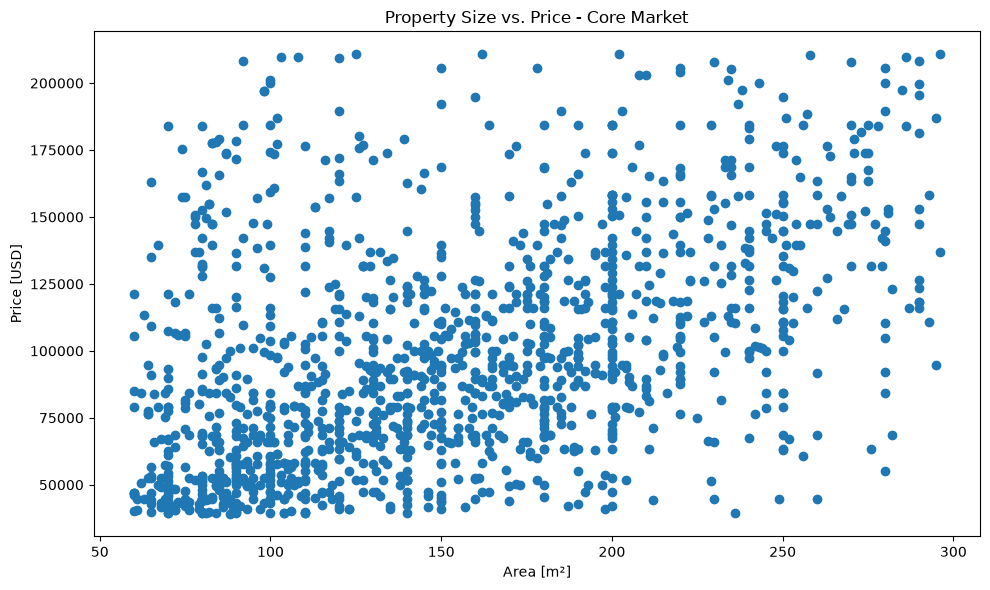

In [41]:
# Plot the core-market observations
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    x=df_clean["area_m2"],
    y=df_clean["price_usd"]
)

ax.set_xlabel("Area [m²]")
ax.set_ylabel("Price [USD]")
ax.set_title("Property Size vs. Price - Core Market")

plt.tight_layout()
plt.show()

### Interpretation

After reducing the influence of extreme observations, the main
pattern becomes easier to see.

The relationship between property size and price appears generally
positive: properties with greater area tend to have higher prices.

However, substantial variation remains. Properties with similar
areas can still have noticeably different prices.

This suggests that property size is an important factor, but other
variables (particularly location) may also contribute substantially
to price differences.

## 11. Add a Regression Trendline

A scatterplot shows the observations individually, but a trendline
can help summarize the overall direction of the relationship.

Seaborn's `regplot()` combines a scatterplot with a fitted linear
regression line and a confidence interval.

The regression line helps answer a simple question:

> Does the average predicted price increase as property size
> increases?

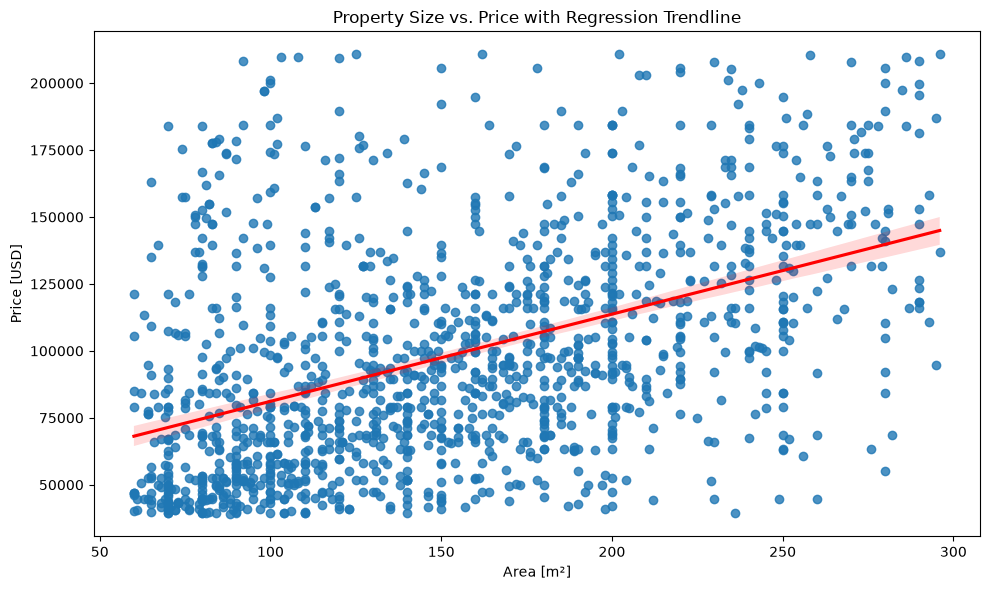

In [42]:
# Create a scatterplot with a regression trendline
fig, ax =plt.subplots(figsize=(10,6))
sns.regplot(
    data=df_clean,
    x="area_m2",
    y="price_usd",
    #color="tab:red",
    line_kws={"color": "red"},
    ax=ax
)
ax.set_xlabel("Area [m²]")
ax.set_ylabel("Price [USD]")
ax.set_title("Property Size vs. Price with Regression Trendline")
plt.tight_layout()
plt.show()

### Interpretation

The regression line slopes upward, indicating a positive association
between property size and price.

In general, larger properties tend to have higher prices.

However, the observations do not lie directly on the regression line.
There is considerable scatter around it.

This means that area alone does not fully explain property prices.

The confidence band also provides information about the uncertainty
around the estimated relationship. A wider band indicates greater
uncertainty in the fitted line.

## 12. Compare Prices Across States

The research question also asks whether location is associated with
property prices.

One way to investigate this is to calculate the average price for
each state.

I use `groupby()` to split the data by state, calculate the mean
price within each group, and then sort the results from highest to
lowest.

In [43]:
# Calculate mean property price by state
mean_price_by_state=(
    df.groupby("state")["price_usd"]
    .mean()
    .sort_values(ascending=False)
)
mean_price_by_state

state
Querétaro                          133955.913417
Guanajuato                         133277.965833
Nuevo León                         129221.985834
Distrito Federal                   128347.267365
Quintana Roo                       128065.415734
Chihuahua                          127073.851184
Jalisco                            123386.472237
Estado de México                   122723.490600
Campeche                           121734.633333
Puebla                             121732.974294
Guerrero                           119854.276015
Sonora                             114547.881798
Morelos                            112697.295615
Aguascalientes                     110543.888316
Baja California Sur                109069.339158
Yucatán                            108580.388526
Chiapas                            104342.313388
Veracruz de Ignacio de la Llave     96928.125254
Hidalgo                             94012.326563
Sinaloa                             93922.152490
Tamaulipas    

The `groupby()` operation follows the **split-apply-combine**
pattern:

1. **Split** the data into groups based on `state`
2. **Apply** `.mean()` to calculate the average price in each state
3. **Combine** the results into a single Series

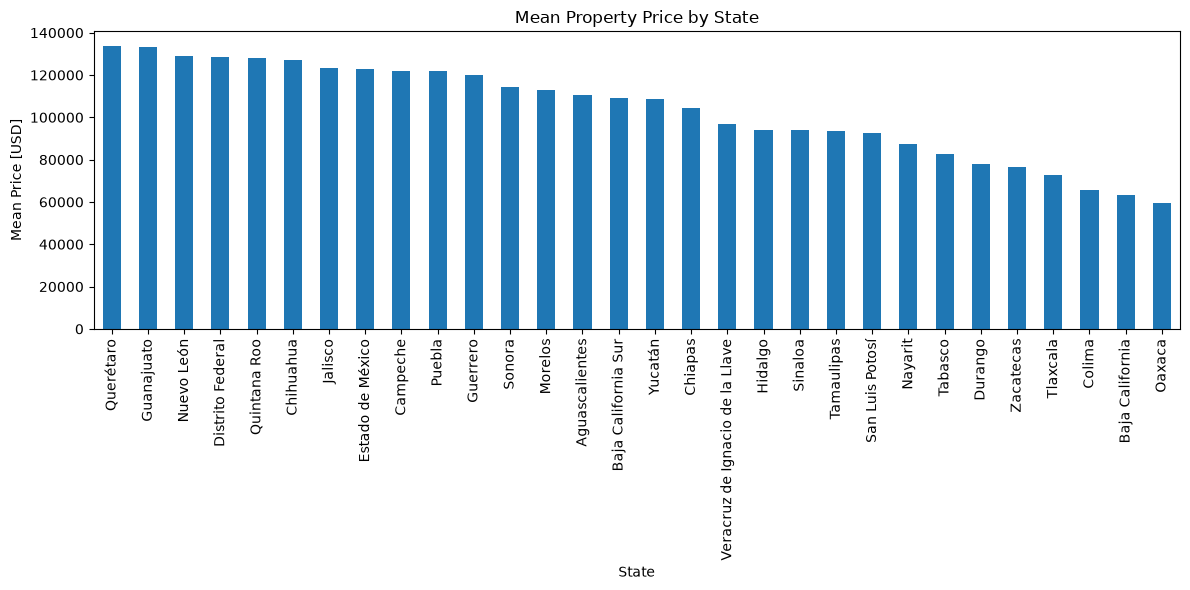

In [44]:
# Visualize mean price by state
fig, ax = plt.subplots(figsize=(12, 6))

mean_price_by_state.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.set_title("Mean Property Price by State")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows substantial differences in average property
prices between states.

This provides additional visual evidence that location is associated
with property prices.

However, the mean is sensitive to extreme observations. Therefore,
these differences should be interpreted cautiously.

A later statistical analysis will use more robust measures and
formal comparisons to quantify the relationship.

## 13. Compare the Size-Price Relationship by State

A single national scatterplot combines properties from many
different markets.

The relationship between property size and price may not be the same
in every state.

To investigate this possibility, I use **small multiples**.

Each panel contains the same type of scatterplot for one state.
Using aligned axes makes differences between the markets easier to
compare visually.

In [45]:
# Select the three states with the most listings
top_states = (
    df_clean["state"]
    .value_counts()
    .head(3)
    .index
    .tolist()
)

top_states

['Distrito Federal', 'Yucatán', 'Estado de México']

In [46]:
# Keep only the selected states
df_states = df_clean[
    df_clean["state"].isin(top_states)
]

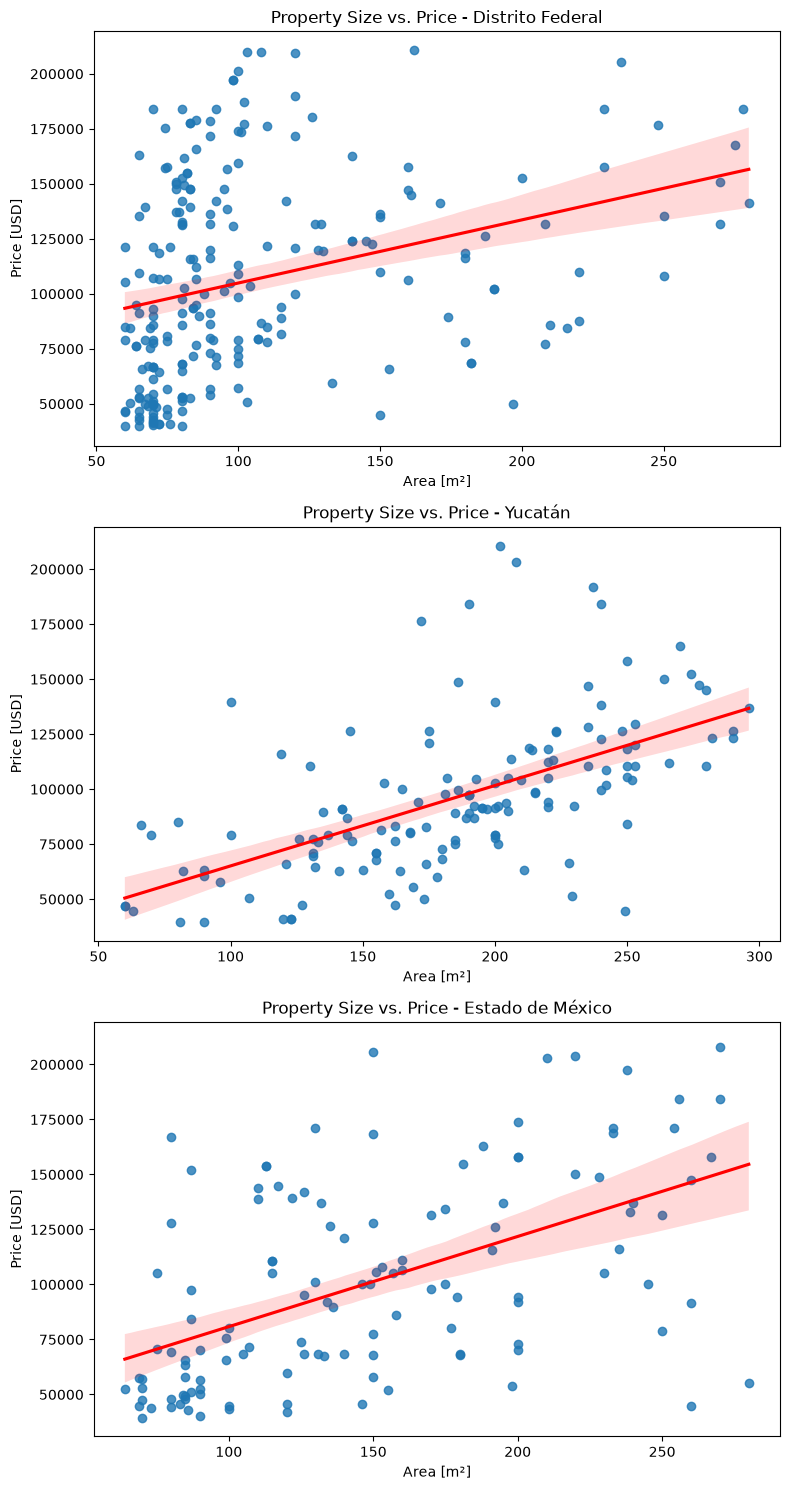

In [47]:
# Create a figure with 3 rows and 1 column of plots
# figsize=(8, 15) controls the overall size of the figure
# sharey=True makes all three plots use the same y-axis scale
fig, axes = plt.subplots(
    3,
    1,
    figsize=(8, 15),
    sharey=True
)

# Loop through each plot (ax) and each state in top_states
# zip() pairs the first axis with the first state, second axis with second state, etc.
for ax, state in zip(axes, top_states):

    # Select only the rows belonging to the current state
    subset = df_states[
        df_states["state"] == state
    ]

    # Create a scatterplot and add a linear regression trendline
    sns.regplot(
        data=subset,       # Use the data for the current state
        x="area_m2",       # Put property size on the x-axis
        y="price_usd",     # Put property price on the y-axis
        line_kws={"color": "red"}, # customize the color of the trendline
        ax=ax              # Draw this plot on the current axis
    )

    # Give the current plot a title containing the state name
    ax.set_title(f"Property Size vs. Price - {state}")

    # Label the x-axis
    ax.set_xlabel("Area [m²]")

    # Label the y-axis
    ax.set_ylabel("Price [USD]")


# Automatically adjust spacing so titles and labels do not overlap
plt.tight_layout()

# Display the completed figure
plt.show()

### Interpretation

The small multiples show that the relationship between property
size and price is not necessarily identical across states.

Some states may show a stronger and more consistent positive
relationship, while others may show greater scatter.

This suggests that location can influence not only the overall price
level, but also how strongly property size is associated with price.

A single national relationship can therefore hide important
differences between local housing markets.

## 14. Findings

The visual analysis provides several important observations:

### Property Prices

Property prices are right-skewed, with most observations
concentrated toward the lower end of the distribution and a smaller
number of high-priced properties forming a long upper tail.

### Property Size

Property sizes are also right-skewed, with most listings occupying
a relatively moderate range and fewer very large properties.

### Property Type

Boxplots show differences in the price distributions of property
types, while also revealing substantial overlap between groups.

### Location

Property prices vary across states, providing visual evidence that
location is associated with differences in property prices.

### Property Size and Price

The scatterplot shows a positive association between property size
and price. However, substantial variation remains around the
trendline, indicating that size alone does not explain property
prices.

### Local Differences

Small multiples show that the size-price relationship can vary
between states. This suggests that a single national relationship
may conceal important local market differences.

## 15. Conclusion

Visualization has provided a clearer understanding of the Mexican
property market than summary statistics alone.

The analysis suggests that both **property size and location are
associated with property prices**, but their relationships are not
uniform across the market.

Property size shows a positive relationship with price, while
differences in price distributions across states indicate an
important geographic component.

The state-level visualizations also suggest that the relationship
between size and price may vary across locations.

These findings are exploratory rather than definitive. Visualization
can reveal patterns and generate hypotheses, but it cannot quantify
the strength or statistical significance of those relationships.

The next stage will therefore use statistical methods to measure
these relationships formally.